In [1]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

import numpy as np

In [72]:
service = QiskitRuntimeService()

In [73]:
string_size = 5
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=string_size*2 + 1)
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


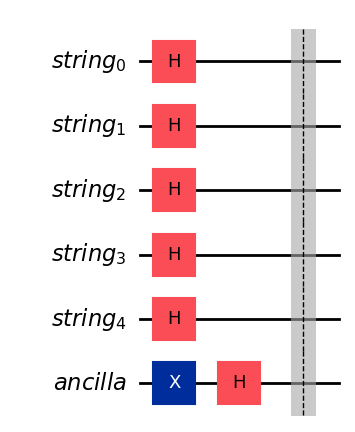

In [87]:
qr = QuantumRegister(string_size, 'string')
cr = ClassicalRegister(string_size, 'measurement')
ancilla = QuantumRegister(1, 'ancilla')
qc = QuantumCircuit(qr, ancilla, cr)
qc.h(qr)
qc.x(ancilla)
qc.h(ancilla)
qc.barrier()
qc.draw(output='mpl', idle_wires=False)

In [79]:
def oracle(qc, s_c, a_c):
    target = 3
    qc.x(s_c[target])
    qc.mcx(s_c, a_c)
    qc.x(s_c[target])
    qc.barrier()

In [62]:
def diffusion(qc, s_c):
    qc.h(s_c)
    qc.x(s_c)
    qc.h(s_c[-1])
    qc.mcx(s_c[:-1], s_c[-1])
    qc.h(s_c[-1])
    qc.x(s_c)
    qc.h(s_c)
    qc.barrier()

In [86]:
import math
t = int(round(math.sqrt(string_size), 0))

/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


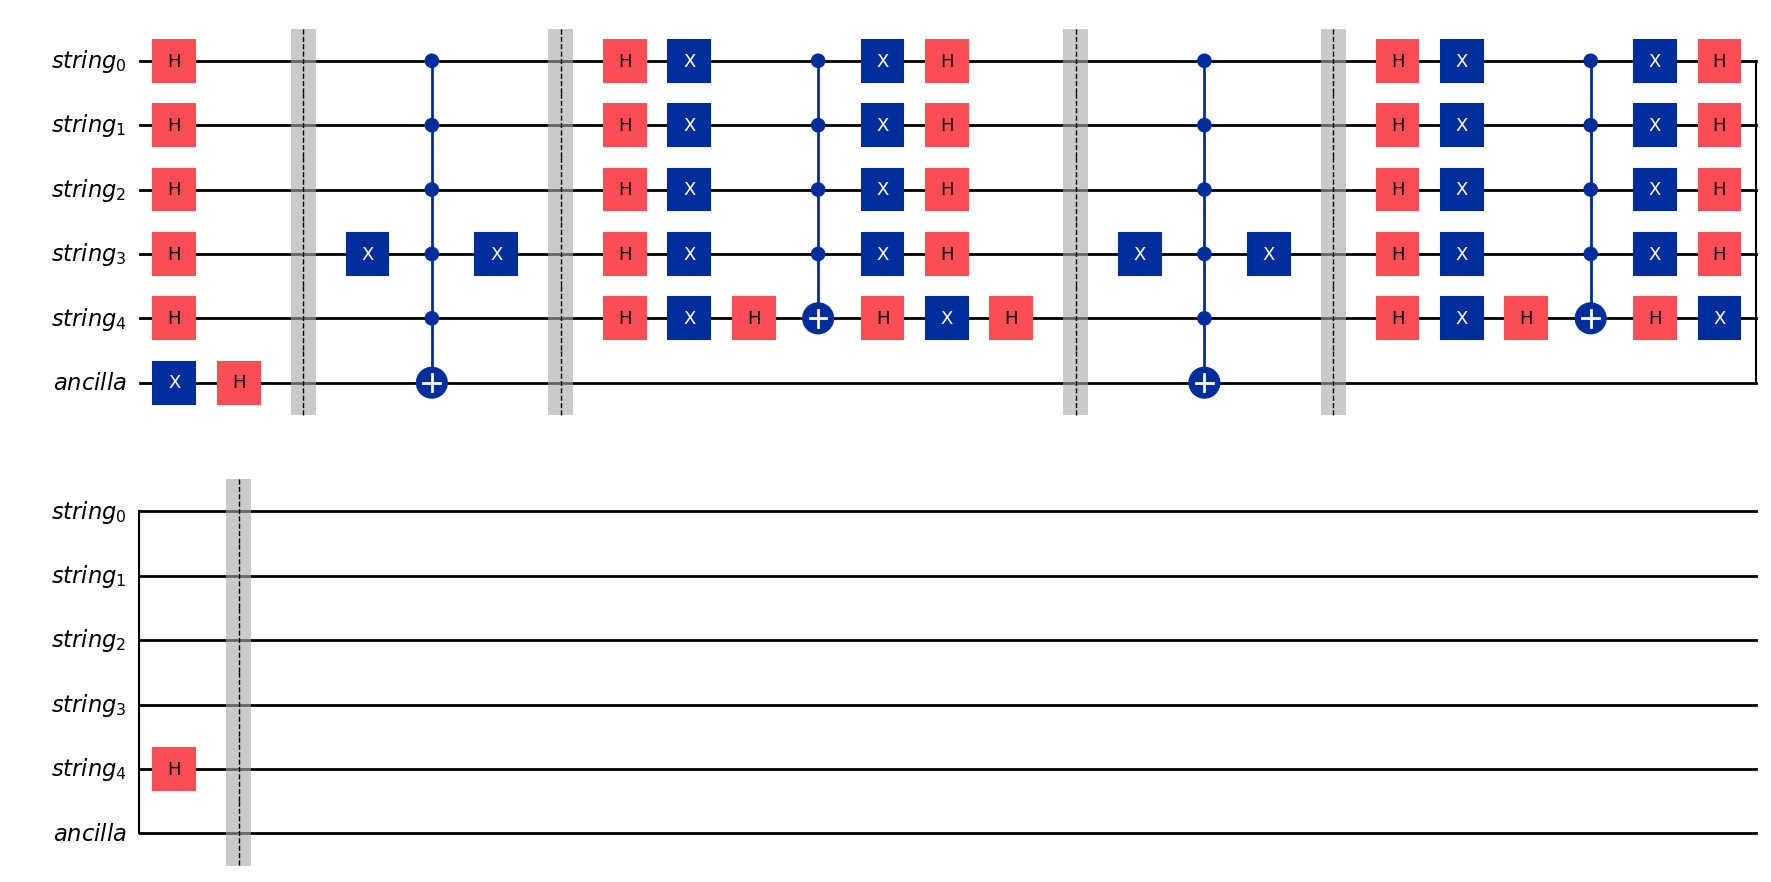

In [88]:
for i in range(t):
    oracle(qc, qr, ancilla)
    diffusion(qc, qr)
qc.draw(output='mpl', idle_wires=False)

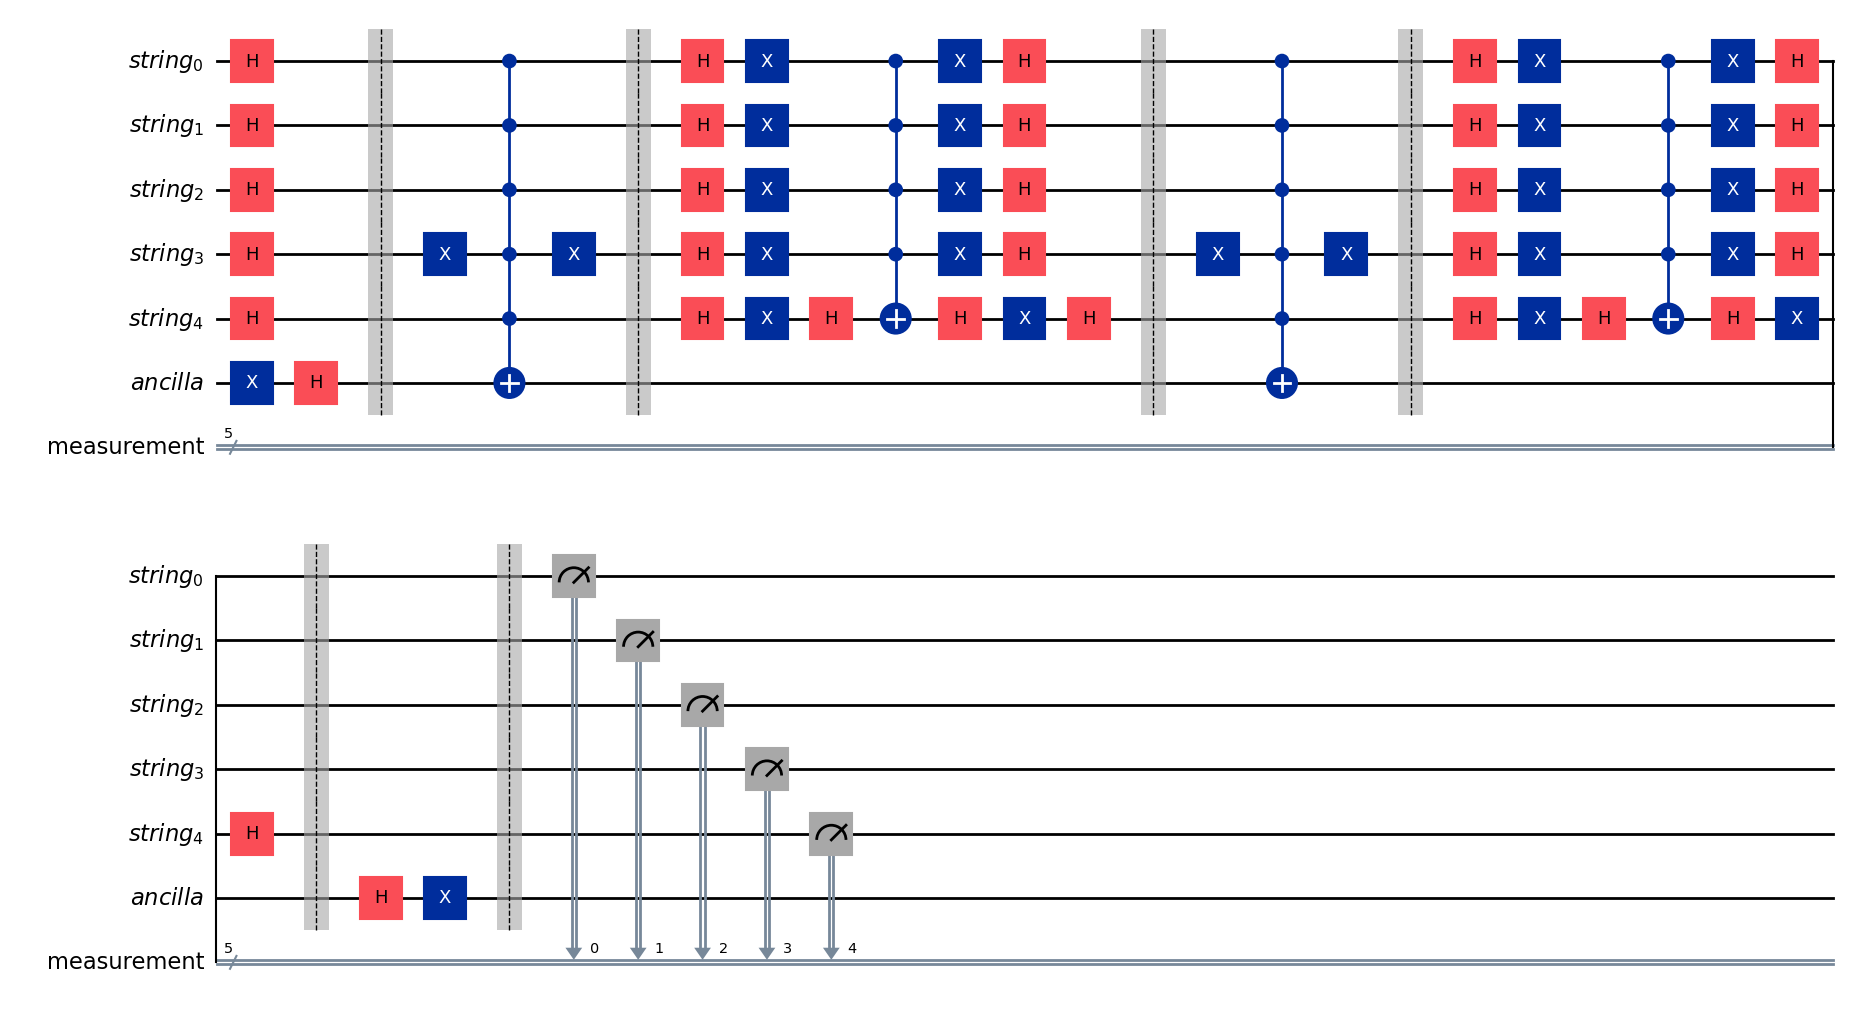

In [89]:
qc.h(ancilla)
qc.x(ancilla)
qc.barrier()
qc.measure(qr, cr)
qc.draw(output='mpl', idle_wires=False)

In [90]:
sampler = Sampler(mode=backend)
isa_qc = pm.run(qc)
job = sampler.run([isa_qc])
result = job.result()
result

PrimitiveResult([SamplerPubResult(data=DataBin(measurement=BitArray(<shape=(), num_shots=4096, num_bits=5>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-03-16 16:11:44', stop='2026-03-16 16:11:49', size=4096>)])}, 'version': 2})

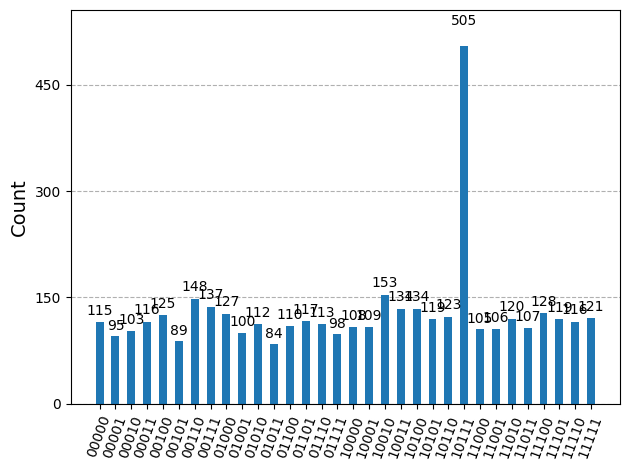

In [91]:
data = result[0].data
m = data['measurement']
plot_histogram(m.get_counts())